# Reaction-library ↔ spectral-data coverage

How much of NIST23 / NIST26's spectral compound space is annotated with a known synthesis
reaction, broken down by reaction source (USPTO_FULL, CAS, Pistachio), and how those three
sources overlap with each other.

**Scope note on `suong`:** `data/{ds}/reaction_metadata_suong.tsv` is not an independent
reaction database like the other three — it's a per-compound retrosynthesis-candidate dump
(rank 1–~200 candidate precursor sets *for every NIST compound*, tagged `source=CAS` inside the
file itself). It covers ~100% of spectral compounds by construction, so a raw overlap count for
it would be a tautology, not a finding. It's reported separately below, not folded into the
3-way Venn with uspto/cas/pistachio.

**Scope note on "library-side" coverage:** `reaction_metadata_*.tsv` files only contain rows
that already matched a NIST compound (that's how they're built — see
`src/mist/build_reaction_metadata.py`). So "how much of USPTO/CAS/Pistachio is *not*
spectrum-annotated" isn't answerable from these join outputs alone — that would need the raw
source libraries' full compound counts, which aren't available in this repo/environment. Only
the USPTO raw source size is known (`/orcd/data/ccoley/001/uspto_data/USPTO_FULL.csv`,
1,808,937 reactions) and is reported for context, not as a percentage.

In [1]:
import warnings
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn3

warnings.filterwarnings("ignore")

# --- style: matches icicle-dev's src/icicle/utils/visualization/style.py ---
# (X90 palette resolved to hex here rather than adding a pypalettes dependency
#  just for a 10-color lookup)
_X90 = [
    "#795998", "#7D4D7F", "#954C84", "#AD5A88", "#D05F95",
    "#DAA7AB", "#F0A9A7", "#E7B7B2", "#EFCCB6", "#D1CAC8", "#B5C5D5",
]
PALETTE = _X90 + ["#D3D3D3", "#A9A9A9", "#808080"]
sns.set_palette(PALETTE)

FIGSIZE = {"default": (3, 2.5), "square": (3, 3), "wide": (6, 2.5), "tall": (3, 4)}


def set_style(style: str = "manuscript") -> None:
    sz = {"manuscript": dict(font=10, label=10, title=10, tick=9, legend=9, major_tick=3),
          "presentation": dict(font=12, label=12, title=12, tick=11, legend=11, major_tick=4)}[style]
    settings = {
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "custom", "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic", "mathtext.bf": "Arial:bold", "mathtext.sf": "Arial",
        "font.size": sz["font"], "axes.labelsize": sz["label"], "axes.titlesize": sz["title"],
        "xtick.labelsize": sz["tick"], "ytick.labelsize": sz["tick"],
        "legend.fontsize": sz["legend"], "legend.title_fontsize": sz["legend"],
        "figure.figsize": FIGSIZE["default"], "figure.dpi": 300,
        "figure.facecolor": "white", "figure.autolayout": False,
        "axes.spines.top": True, "axes.spines.right": True,
        "axes.linewidth": 1.4, "axes.edgecolor": "black", "axes.labelcolor": "black",
        "axes.axisbelow": True, "axes.xmargin": 0.02, "axes.ymargin": 0.02,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.size": sz["major_tick"], "ytick.major.size": sz["major_tick"],
        "xtick.major.width": 1.2, "ytick.major.width": 1.2,
        "xtick.minor.size": 1.5, "ytick.minor.size": 1.5,
        "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
        "xtick.minor.visible": True, "ytick.minor.visible": True,
        "xtick.top": False, "ytick.right": False,
        "xtick.color": "black", "ytick.color": "black",
        "lines.linewidth": 1.0, "lines.markersize": 4,
        "hatch.linewidth": 0.5, "grid.linewidth": 0.5,
        "legend.frameon": False, "legend.fancybox": False,
        "legend.facecolor": "none", "legend.edgecolor": "none",
        "legend.handlelength": 1.5, "legend.handletextpad": 0.4,
        "text.color": "black",
        "axes.prop_cycle": plt.cycler("color", PALETTE[:8]),
    }
    for k, v in settings.items():
        mpl.rcParams[k] = v


def make_fig(size="default", nrows=1, ncols=1, sharex=False, sharey=False, **kw):
    plot_w, plot_h = FIGSIZE[size] if isinstance(size, str) else size
    pad_left, pad_right, pad_bottom, pad_top = 0.55, 0.10, 0.45, 0.15
    fig_w = plot_w * ncols + pad_left + pad_right
    fig_h = plot_h * nrows + pad_bottom + pad_top
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=sharex, sharey=sharey, **kw)
    fig.subplots_adjust(
        left=pad_left / fig_w, right=1.0 - pad_right / fig_w,
        bottom=pad_bottom / fig_h, top=1.0 - pad_top / fig_h,
    )
    return fig, axes


set_style("manuscript")

## Load spectral compound sets (NIST23, NIST26)

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NIST_ROOT = "/orcd/data/ccoley/001/msms_data"
SOURCES = ["uspto", "cas", "pistachio"]  # peer reaction libraries (excludes suong, see note above)

spec_ikeys = {}
for ds in ["nist23", "nist26"]:
    labels = pd.read_csv(f"{NIST_ROOT}/{ds}/labels.tsv", sep="\t", usecols=["spec", "inchikey"])
    spec_ikeys[ds] = set(labels["inchikey"].dropna())
    print(f"{ds}: {len(labels):>7,} spectra, {len(spec_ikeys[ds]):>6,} unique compounds")

nist23: 176,851 spectra, 47,421 unique compounds


nist26: 402,258 spectra, 65,295 unique compounds


## Load reaction-metadata compound sets, per source, per dataset

In [3]:
rxn_ikeys = {}   # rxn_ikeys[ds][source] = set of inchikeys, restricted to spectral compounds
rxn_raw = {}     # rxn_raw[ds][source] = raw dataframe (for reaction-count-per-compound stats)

for ds in ["nist23", "nist26"]:
    rxn_ikeys[ds] = {}
    rxn_raw[ds] = {}
    for src in SOURCES + ["suong"]:
        df = pd.read_csv(REPO_ROOT / f"data/{ds}/reaction_metadata_{src}.tsv", sep="\t")
        rxn_raw[ds][src] = df
        rxn_ikeys[ds][src] = set(df["inchikey"].dropna()) & spec_ikeys[ds]

## Venn diagrams: USPTO / CAS / Pistachio overlap (restricted to spectral compounds)

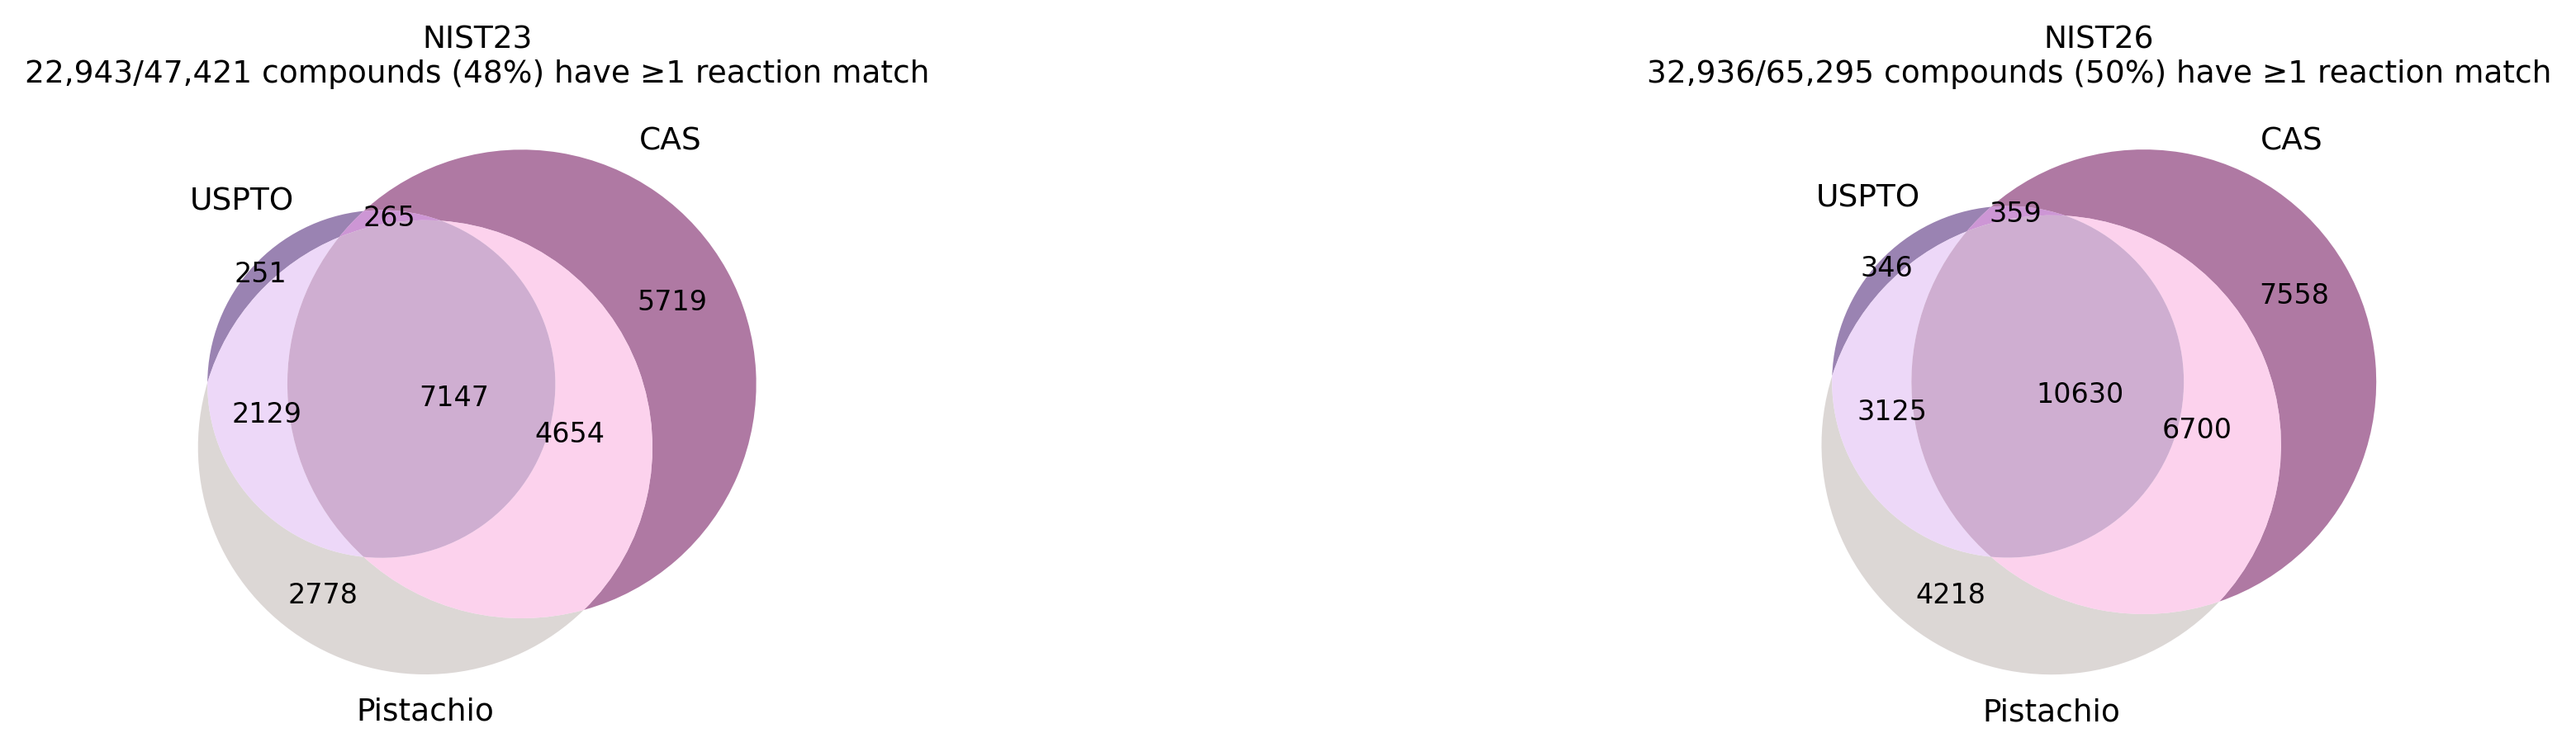

In [4]:
fig, axes = make_fig("wide", ncols=2)

for ax, ds in zip(axes, ["nist23", "nist26"]):
    sets = [rxn_ikeys[ds][s] for s in SOURCES]
    v = venn3(sets, set_labels=["USPTO", "CAS", "Pistachio"], ax=ax,
              set_colors=[PALETTE[0], PALETTE[2], PALETTE[9]], alpha=0.75)
    for text in v.set_labels:
        if text is not None:
            text.set_fontsize(9)
    for text in v.subset_labels:
        if text is not None:
            text.set_fontsize(8)
    n_total = len(spec_ikeys[ds])
    n_any = len(set().union(*sets))
    ax.set_title(f"{ds.upper()}\n{n_any:,}/{n_total:,} compounds ({100*n_any/n_total:.0f}%) have \u22651 reaction match",
                 fontsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

save_fig = lambda fig, name, output_dir=".": (fig.savefig(f"{output_dir}/{name}.svg", bbox_inches="tight"),
                                                fig.savefig(f"{output_dir}/{name}.pdf", bbox_inches="tight"))
plt.show()

## Coverage summary table (per source, per dataset)

In [5]:
rows = []
for ds in ["nist23", "nist26"]:
    n_total = len(spec_ikeys[ds])
    for src in SOURCES + ["suong"]:
        matched = rxn_ikeys[ds][src]
        counts = rxn_raw[ds][src].groupby("inchikey").size()
        rows.append({
            "dataset": ds, "source": src,
            "matched_compounds": len(matched),
            "pct_of_spectral": round(100 * len(matched) / n_total, 1),
            "total_rows": len(rxn_raw[ds][src]),
            "median_matches_per_compound": counts.median(),
            "mean_matches_per_compound": round(counts.mean(), 1),
            "max_matches_per_compound": counts.max(),
        })
    any3 = set().union(*[rxn_ikeys[ds][s] for s in SOURCES])
    rows.append({
        "dataset": ds, "source": "ANY of uspto/cas/pistachio",
        "matched_compounds": len(any3),
        "pct_of_spectral": round(100 * len(any3) / n_total, 1),
        "total_rows": None, "median_matches_per_compound": None,
        "mean_matches_per_compound": None, "max_matches_per_compound": None,
    })
    rows.append({
        "dataset": ds, "source": "NONE (no reaction match)",
        "matched_compounds": n_total - len(any3),
        "pct_of_spectral": round(100 * (n_total - len(any3)) / n_total, 1),
        "total_rows": None, "median_matches_per_compound": None,
        "mean_matches_per_compound": None, "max_matches_per_compound": None,
    })

summary = pd.DataFrame(rows)
summary

,dataset,source,matched_compounds,pct_of_spectral,total_rows,median_matches_per_compound,mean_matches_per_compound,max_matches_per_compound
0,nist23,uspto,9792,20.6,64633.0,2.0,6.6,3877.0
1,nist23,cas,17785,37.5,57012.0,1.0,3.2,393.0
2,nist23,pistachio,16708,35.2,56222.0,2.0,3.4,517.0
3,nist23,suong,47421,100.0,4742200.0,100.0,100.0,200.0
4,nist23,ANY of uspto/cas/pistachio,22943,48.4,NaN,NaN,NaN,NaN
5,nist23,NONE (no reaction match),24478,51.6,NaN,NaN,NaN,NaN
6,nist26,uspto,14460,22.1,87110.0,2.0,6.0,3877.0
7,nist26,cas,25247,38.7,72546.0,1.0,2.9,334.0
8,nist26,pistachio,24673,37.8,77245.0,2.0,3.1,517.0
9,nist26,suong,62016,95.0,6517600.0,100.0,100.0,200.0


## Bar chart: annotated vs. un-annotated spectral compounds

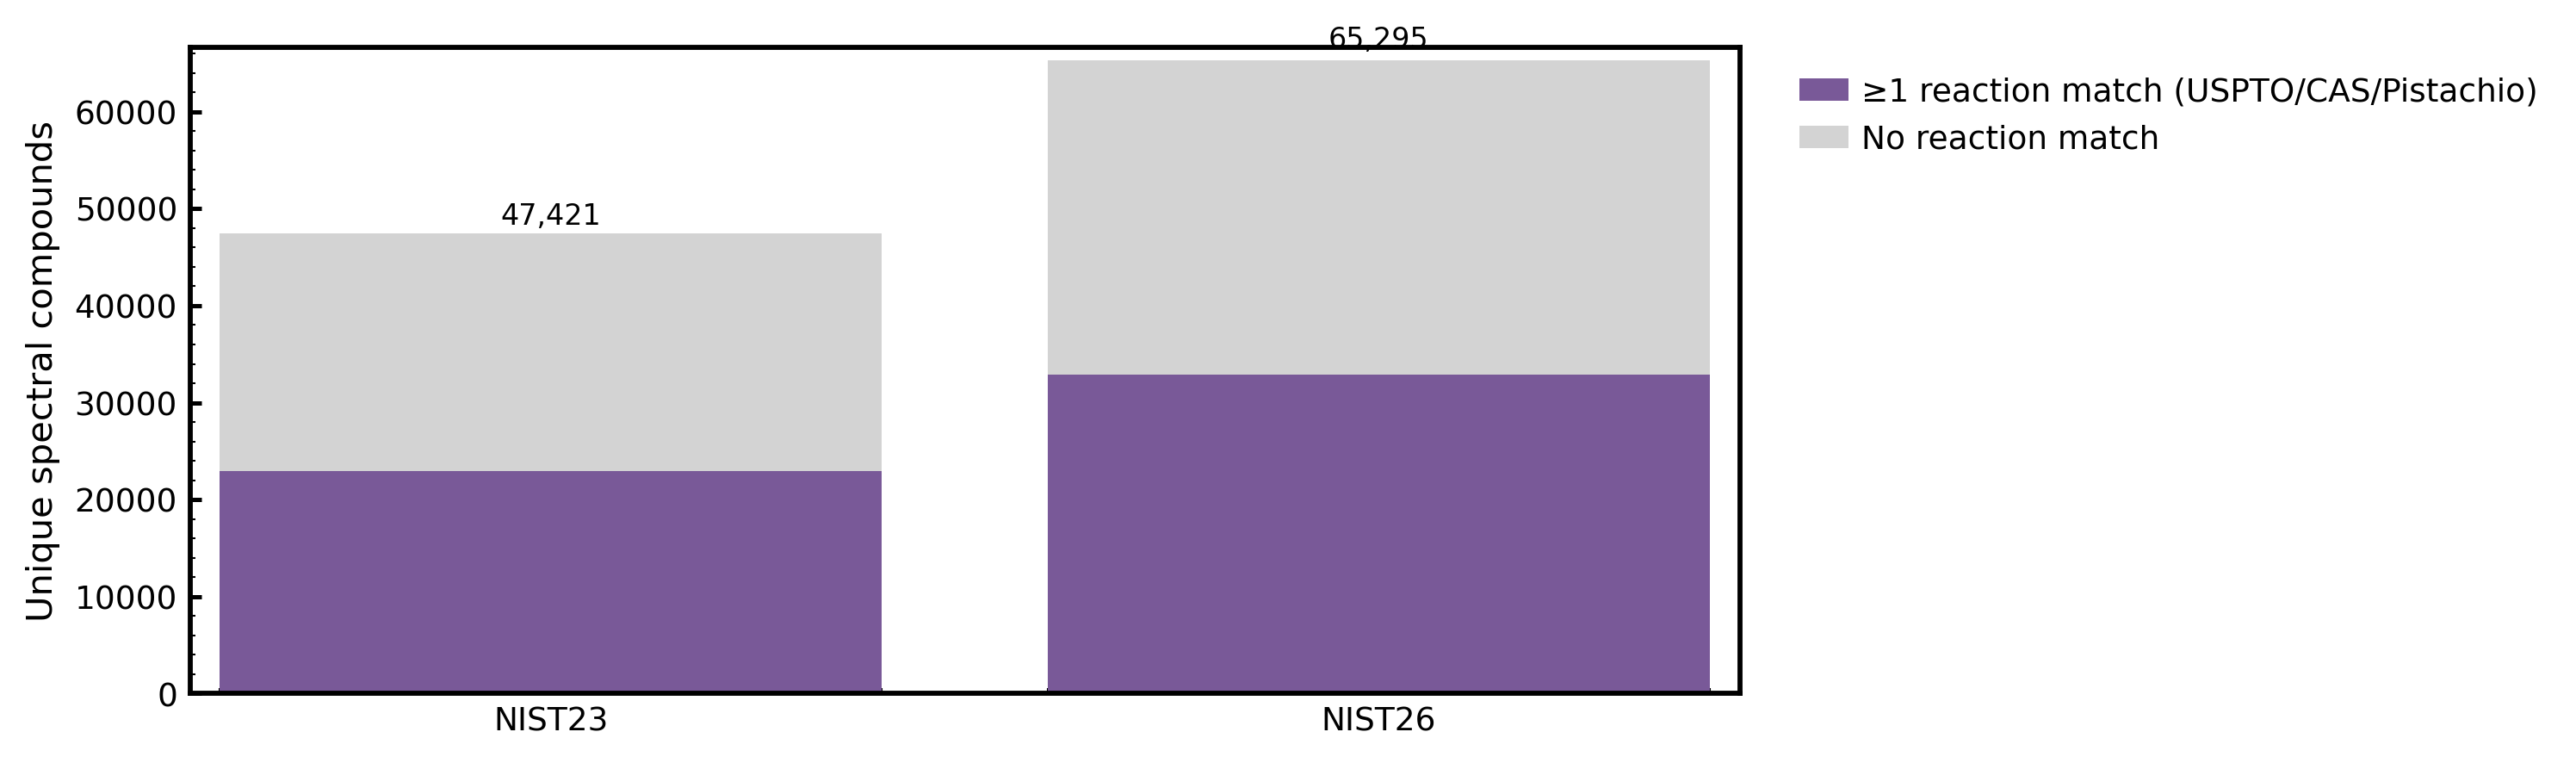

In [6]:
fig, ax = make_fig("wide")

datasets = ["nist23", "nist26"]
any3_counts = [len(set().union(*[rxn_ikeys[ds][s] for s in SOURCES])) for ds in datasets]
totals = [len(spec_ikeys[ds]) for ds in datasets]
none_counts = [t - a for t, a in zip(totals, any3_counts)]

x = range(len(datasets))
ax.bar(x, any3_counts, label="\u22651 reaction match (USPTO/CAS/Pistachio)", color=PALETTE[0])
ax.bar(x, none_counts, bottom=any3_counts, label="No reaction match", color=PALETTE[11])
ax.set_xticks(list(x))
ax.set_xticklabels([d.upper() for d in datasets])
ax.set_ylabel("Unique spectral compounds")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
for xi, t in zip(x, totals):
    ax.text(xi, t * 1.02, f"{t:,}", ha="center", fontsize=8)
plt.show()

## Context: raw USPTO_FULL source size (library side, not NIST-filtered)

This is the only raw reaction-library size available in this environment (CAS/Pistachio raw
libraries were not built from a script present in this repo, so their un-filtered sizes aren't
recoverable here). Reported for scale only — not comparable to the NIST-filtered `matched_compounds`
counts above without knowing CAS/Pistachio's own raw sizes too.

In [7]:
USPTO_FULL_PATH = "/orcd/data/ccoley/001/uspto_data/USPTO_FULL.csv"
with open(USPTO_FULL_PATH) as f:
    n_uspto_full = sum(1 for _ in f) - 1  # minus header
print(f"USPTO_FULL.csv: {n_uspto_full:,} raw reaction rows")
for ds in ["nist23", "nist26"]:
    print(f"  -> {len(rxn_ikeys[ds]['uspto']):,} of {len(spec_ikeys[ds]):,} {ds} spectral "
          f"compounds ({100*len(rxn_ikeys[ds]['uspto'])/len(spec_ikeys[ds]):.1f}%) appear as a product")

USPTO_FULL.csv: 1,808,937 raw reaction rows
  -> 9,792 of 47,421 nist23 spectral compounds (20.6%) appear as a product
  -> 14,460 of 65,295 nist26 spectral compounds (22.1%) appear as a product
